# Data-Handling Visual Report
## Lecture 5 — Vorher/Nachher-Analyse

Dieses Notebook dokumentiert jeden Schritt des Data-Handling-Workflows visuell.  
Jede Aufgabe wird mit **Vorher/Nachher-Plots** dargestellt, sodass Bereinigungsentscheidungen auf einen Blick nachvollziehbar sind.

> **Kontext:** Erstellt als Demonstration, wie Claude den Data-Handling-Workflow beschleunigt — von der Diagnose über die Bereinigung bis zum fertigen Report.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

# --- Style -----------------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f8f9fa",
    "axes.edgecolor": "#dee2e6",
    "axes.grid": True,
    "grid.color": "#e9ecef",
    "grid.linewidth": 0.6,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "figure.titlesize": 15,
    "figure.titleweight": "bold",
    "figure.dpi": 120,
})

C_BEFORE = "#e74c3c"   # rot  — Vorher / Probleme
C_AFTER  = "#2ecc71"   # grün — Nachher / bereinigt
C_ACCENT = "#3498db"   # blau — neutrale Akzente
C_WARN   = "#f39c12"   # gelb — Warnungen

pd.set_option("display.max_columns", 60)
print("Setup abgeschlossen.")

Setup abgeschlossen.


---
## Aufgabe 1 — Rohdaten laden

Erster Blick auf den Datensatz: Dimensionen, Spaltentypen und eine Stichprobe der Rohdaten.

In [2]:
raw = pd.read_csv("../lecture_05_employee_survey_raw.csv")

print(f"Dimensionen:  {raw.shape[0]} Zeilen × {raw.shape[1]} Spalten")
print(f"Spalten:      {raw.columns.tolist()}")
raw.head(10)

Dimensionen:  81 Zeilen × 18 Spalten
Spalten:      ['participant_id', 'department', 'gender', 'age', 'weekly_hours', 'sleep_hours', 'commute_minutes', 'workload_1', 'workload_2', 'autonomy_1', 'autonomy_2', 'support_1', 'support_2', 'stress_score', 'motivation', 'satisfaction', 'performance_rating', 'absent_days']


,participant_id,department,gender,age,weekly_hours,sleep_hours,commute_minutes,workload_1,workload_2,autonomy_1,autonomy_2,support_1,support_2,stress_score,motivation,satisfaction,performance_rating,absent_days
0,P001,HR,Male,42.0,45.4,8.6,21.0,4.0,4,3,4,3,2.0,54.0,3.3,3.2,3.1,4.0
1,P002,Operations,Male,22.0,45.3,5.8,30.0,4.0,4,4,3,5,5.0,33.0,4.0,4.1,4.5,3.0
2,P003,Marketing,Female,36.0,33.1,9.1,26.0,3.0,3,4,4,2,2.0,37.0,3.9,3.2,3.5,0.0
3,P004,sales,Female,47.0,35.3,5.0,23.0,3.0,3,4,4,2,1.0,54.0,2.8,3.2,3.4,2.0
4,P005,Sales,Female,25.0,42.6,6.8,23.0,3.0,3,3,3,2,2.0,49.0,3.8,2.9,3.3,2.0
5,P006,IT,Female,28.0,42.6,7.6,32.0,3.0,2,3,3,2,3.0,42.0,3.5,2.7,3.9,3.0
6,P007,Sales,Male,33.0,42.6,7.3,79.0,2.0,3,4,3,4,4.0,32.0,3.7,4.6,4.3,1.0
7,P008,Operations,Male,28.0,59.3,6.4,12.0,3.0,3,2,3,4,4.0,31.0,3.9,3.0,3.8,0.0
8,P009,MKT,Male,21.0,42.9,6.8,81.0,3.0,3,3,2,4,3.0,42.0,3.7,2.7,3.5,2.0
9,P010,Marketing,Female,32.0,45.7,6.5,12.0,2.0,3,4,5,4,3.0,31.0,3.6,4.6,3.9,1.0


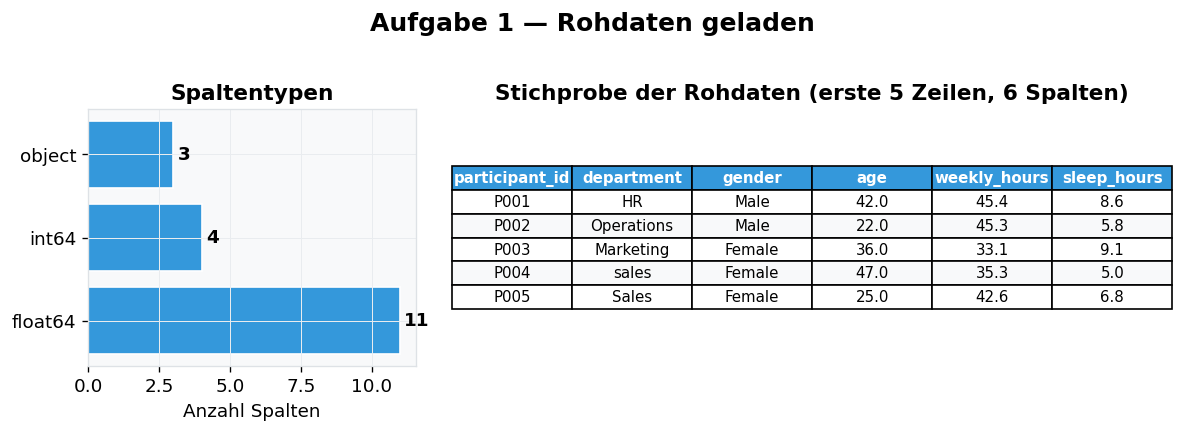

In [3]:
# Überblick: Datentypen-Verteilung
dtype_counts = raw.dtypes.map(lambda d: d.name).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), gridspec_kw={"width_ratios": [1, 2.2]})

# Links: Dtype-Verteilung
axes[0].barh(dtype_counts.index, dtype_counts.values, color=C_ACCENT, edgecolor="white")
axes[0].set_title("Spaltentypen")
axes[0].set_xlabel("Anzahl Spalten")
for i, v in enumerate(dtype_counts.values):
    axes[0].text(v + 0.15, i, str(v), va="center", fontweight="bold")

# Rechts: Erste Zeilen als Tabelle
sample = raw.iloc[:5, :6]
axes[1].axis("off")
tbl = axes[1].table(
    cellText=sample.values,
    colLabels=sample.columns,
    loc="center",
    cellLoc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.5)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor(C_ACCENT)
        cell.set_text_props(color="white", fontweight="bold")
    else:
        cell.set_facecolor("#f8f9fa" if row % 2 == 0 else "white")
axes[1].set_title("Stichprobe der Rohdaten (erste 5 Zeilen, 6 Spalten)")

fig.suptitle("Aufgabe 1 — Rohdaten geladen", y=1.02)
plt.tight_layout()
plt.show()

---
## Aufgabe 2 — Data Audit

Systematische Diagnose: Wo fehlen Werte? Welche numerischen Variablen haben verdächtige Bereiche?

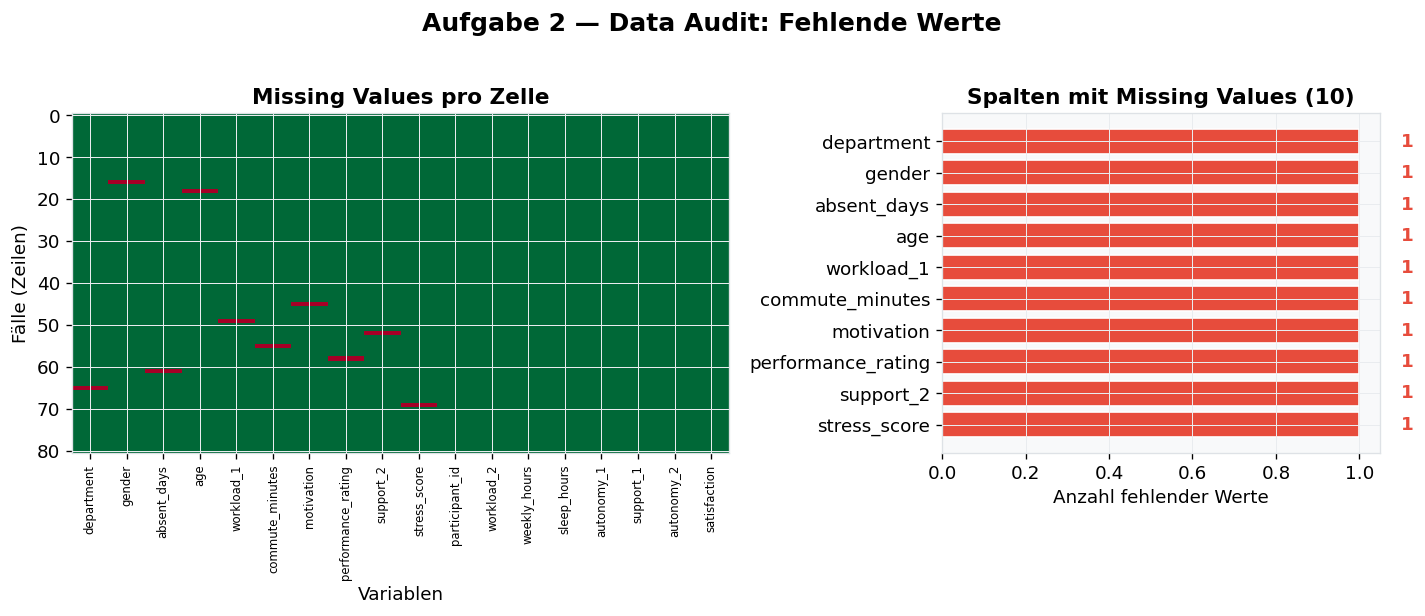


Gesamt fehlende Zellen: 10 von 1458 (0.7 %)


In [4]:
# --- Missing-Value-Heatmap ---------------------------------------------------
missing = raw.isna()
missing_counts = missing.sum().sort_values(ascending=False)
cols_with_missing = missing_counts[missing_counts > 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [1.5, 1]})

# Links: Heatmap aller Spalten (Zeilen = Fälle, Spalten = Variablen)
ax = axes[0]
sorted_cols = missing_counts.index.tolist()
heatmap_data = missing[sorted_cols].values.astype(float)
im = ax.imshow(heatmap_data, aspect="auto", cmap="RdYlGn_r", interpolation="nearest", vmin=0, vmax=1)
ax.set_xlabel("Variablen")
ax.set_ylabel("Fälle (Zeilen)")
ax.set_xticks(range(len(sorted_cols)))
ax.set_xticklabels(sorted_cols, rotation=90, fontsize=7)
ax.set_title("Missing Values pro Zelle")

# Rechts: Balkendiagramm fehlende Werte
ax2 = axes[1]
if len(cols_with_missing) > 0:
    bars = ax2.barh(cols_with_missing.index, cols_with_missing.values, color=C_BEFORE, edgecolor="white")
    ax2.set_xlabel("Anzahl fehlender Werte")
    ax2.set_title(f"Spalten mit Missing Values ({len(cols_with_missing)})")
    ax2.invert_yaxis()
    for bar, v in zip(bars, cols_with_missing.values):
        ax2.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
                 str(v), va="center", fontweight="bold", color=C_BEFORE)
else:
    ax2.text(0.5, 0.5, "Keine fehlenden Werte", ha="center", va="center", transform=ax2.transAxes)

fig.suptitle("Aufgabe 2 — Data Audit: Fehlende Werte", y=1.02)
plt.tight_layout()
plt.show()

print(f"\nGesamt fehlende Zellen: {missing.sum().sum()} von {raw.shape[0] * raw.shape[1]} ({missing.sum().sum() / (raw.shape[0] * raw.shape[1]) * 100:.1f} %)")

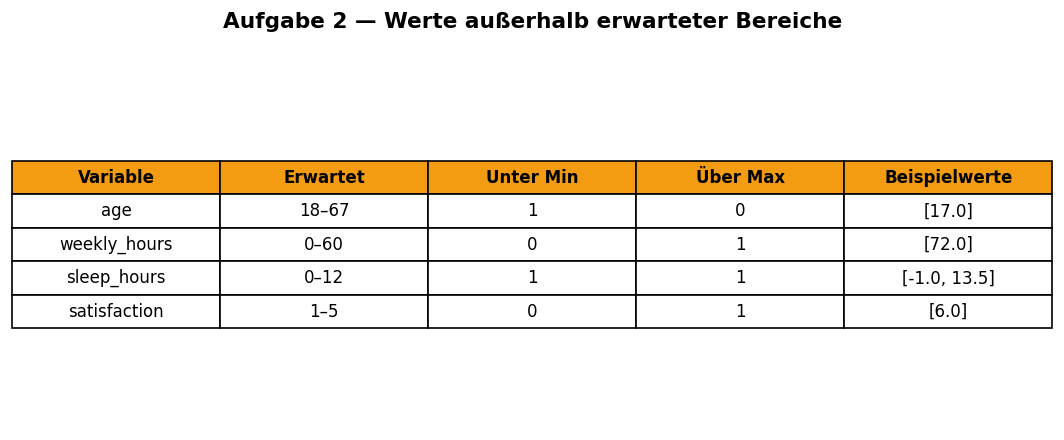

In [5]:
# --- Audit: Numerische Wertebereiche ----------------------------------------
# Erwartete Bereiche laut Codebook
expected_ranges = {
    "age": (18, 67), "weekly_hours": (0, 60), "sleep_hours": (0, 12),
    "commute_minutes": (0, 180), "stress_score": (0, 100),
    "motivation": (1, 5), "satisfaction": (1, 5), "performance_rating": (1, 5),
    "absent_days": (0, 60),
    "workload_1": (1, 5), "workload_2": (1, 5),
    "autonomy_1": (1, 5), "autonomy_2": (1, 5),
    "support_1": (1, 5), "support_2": (1, 5),
}

problems = []
for col, (lo, hi) in expected_ranges.items():
    if col in raw.columns:
        vals = pd.to_numeric(raw[col], errors="coerce")
        n_below = (vals < lo).sum()
        n_above = (vals > hi).sum()
        if n_below > 0 or n_above > 0:
            examples = vals[(vals < lo) | (vals > hi)].dropna().tolist()
            problems.append({"Variable": col, "Erwartet": f"{lo}–{hi}",
                             "Unter Min": n_below, "Über Max": n_above,
                             "Beispielwerte": examples[:3]})

problems_df = pd.DataFrame(problems)

fig, ax = plt.subplots(figsize=(9, max(2.5, len(problems) * 0.7 + 1)))
ax.axis("off")
if len(problems_df) > 0:
    tbl = ax.table(
        cellText=problems_df.values,
        colLabels=problems_df.columns,
        loc="center", cellLoc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 1.6)
    for (row, col), cell in tbl.get_celld().items():
        if row == 0:
            cell.set_facecolor(C_WARN)
            cell.set_text_props(fontweight="bold")
        elif any(problems_df.iloc[row - 1][c] > 0 for c in ["Unter Min", "Über Max"] if isinstance(problems_df.iloc[row - 1][c], (int, float))):
            cell.set_facecolor("#ffeaa7")
ax.set_title("Aufgabe 2 — Werte außerhalb erwarteter Bereiche", fontsize=13, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

---
## Aufgabe 3 — Kategorien bereinigen

Inkonsistente Schreibweisen in `department` und `gender` werden zusammengeführt.

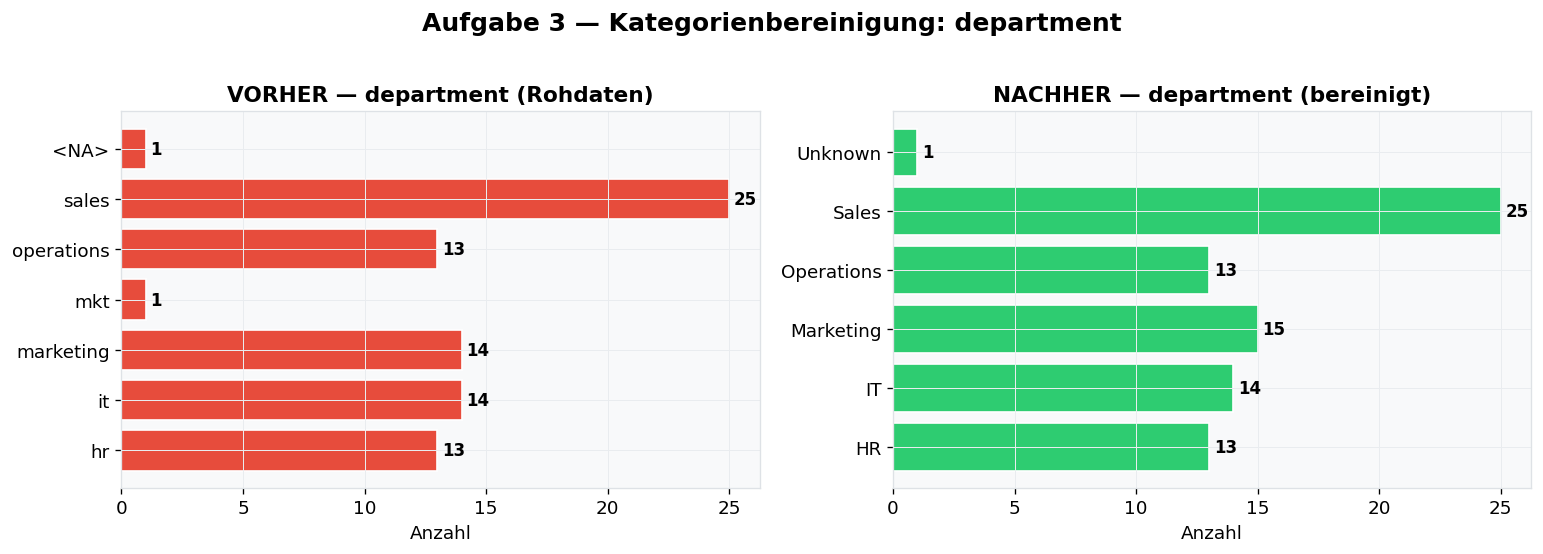

In [6]:
# --- Bereinigung durchführen -------------------------------------------------
clean = raw.copy()
clean.columns = [c.strip().lower() for c in clean.columns]

# department
clean["department"] = clean["department"].astype("string").str.strip().str.lower()
dept_map = {"sales": "Sales", "hr": "HR", "it": "IT",
            "mkt": "Marketing", "marketing": "Marketing", "operations": "Operations"}
dept_before = clean["department"].value_counts(dropna=False).copy()
clean["department"] = clean["department"].replace(dept_map).fillna("Unknown")
dept_after = clean["department"].value_counts(dropna=False)

# gender
clean["gender"] = clean["gender"].astype("string").str.strip().str.lower()
gender_map = {"f": "Female", "female": "Female", "m": "Male", "male": "Male",
              "nonbinary": "Nonbinary", "prefer not to say": "Prefer not to say", "": "Unknown"}
gender_before = clean["gender"].replace(gender_map)  # just for counting raw
gender_before_raw = raw["gender"].value_counts(dropna=False)
clean["gender"] = clean["gender"].replace(gender_map).fillna("Unknown")
gender_after = clean["gender"].value_counts(dropna=False)

# --- Vorher/Nachher-Plot: department ----------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)

# Vorher
ax = axes[0]
dept_before_sorted = dept_before.sort_index()
bars = ax.barh(dept_before_sorted.index.astype(str), dept_before_sorted.values, color=C_BEFORE, edgecolor="white")
ax.set_title("VORHER — department (Rohdaten)")
ax.set_xlabel("Anzahl")
for bar, v in zip(bars, dept_before_sorted.values):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
            str(v), va="center", fontweight="bold", fontsize=10)

# Nachher
ax2 = axes[1]
dept_after_sorted = dept_after.sort_index()
bars2 = ax2.barh(dept_after_sorted.index, dept_after_sorted.values, color=C_AFTER, edgecolor="white")
ax2.set_title("NACHHER — department (bereinigt)")
ax2.set_xlabel("Anzahl")
for bar, v in zip(bars2, dept_after_sorted.values):
    ax2.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
             str(v), va="center", fontweight="bold", fontsize=10)

fig.suptitle("Aufgabe 3 — Kategorienbereinigung: department", y=1.02)
plt.tight_layout()
plt.show()

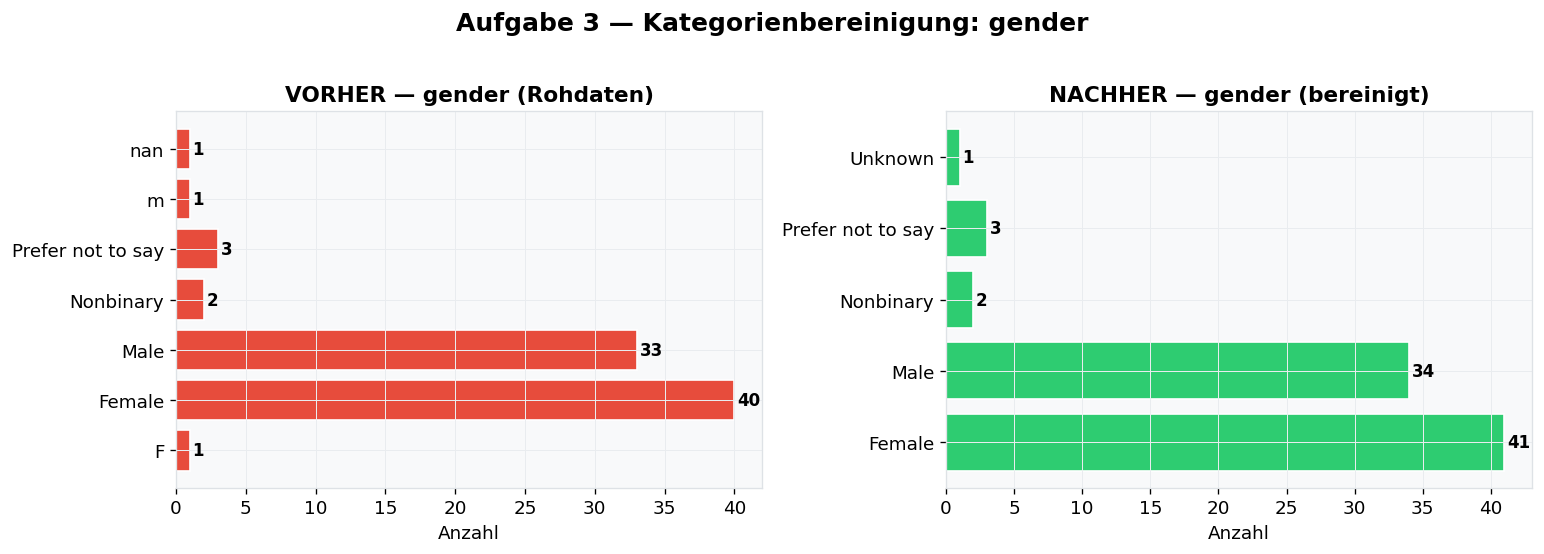

department: 7 Kategorien → 6 Kategorien
gender:     7 Kategorien → 5 Kategorien


In [7]:
# --- Vorher/Nachher-Plot: gender ---------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)

# Vorher
ax = axes[0]
gb_sorted = gender_before_raw.sort_index()
bars = ax.barh(gb_sorted.index.astype(str), gb_sorted.values, color=C_BEFORE, edgecolor="white")
ax.set_title("VORHER — gender (Rohdaten)")
ax.set_xlabel("Anzahl")
for bar, v in zip(bars, gb_sorted.values):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
            str(v), va="center", fontweight="bold", fontsize=10)

# Nachher
ax2 = axes[1]
ga_sorted = gender_after.sort_index()
bars2 = ax2.barh(ga_sorted.index, ga_sorted.values, color=C_AFTER, edgecolor="white")
ax2.set_title("NACHHER — gender (bereinigt)")
ax2.set_xlabel("Anzahl")
for bar, v in zip(bars2, ga_sorted.values):
    ax2.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
             str(v), va="center", fontweight="bold", fontsize=10)

fig.suptitle("Aufgabe 3 — Kategorienbereinigung: gender", y=1.02)
plt.tight_layout()
plt.show()

print(f"department: {dept_before.shape[0]} Kategorien → {dept_after.shape[0]} Kategorien")
print(f"gender:     {gender_before_raw.shape[0]} Kategorien → {gender_after.shape[0]} Kategorien")

---
## Aufgabe 4 — Doppelte IDs und gültige Wertebereiche

Doppelte `participant_id` entfernen. Werte außerhalb plausibler Grenzen auf `NaN` setzen.

Doppelte IDs gefunden: ['P010']
Zeilen vorher: 81 → nachher: 80 (entfernt: 1)



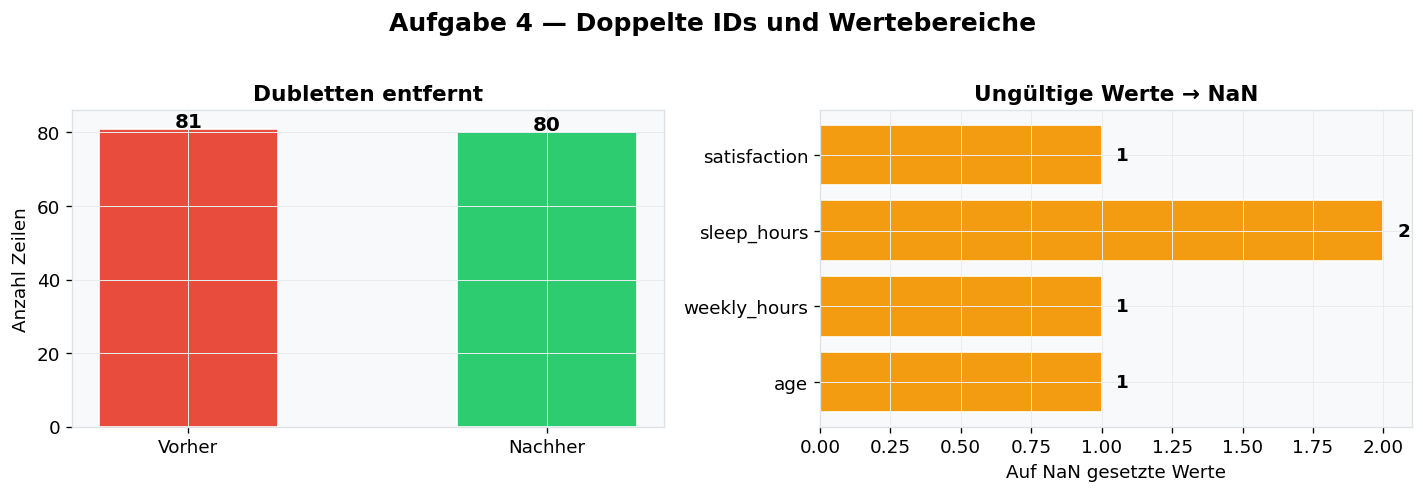

In [8]:
# --- Doppelte IDs -----------------------------------------------------------
duplicates = clean[clean.duplicated(subset="participant_id", keep=False)].sort_values("participant_id")
n_before = len(clean)
clean = clean.drop_duplicates(subset="participant_id", keep="first").reset_index(drop=True)
n_after = len(clean)

print(f"Doppelte IDs gefunden: {duplicates['participant_id'].unique().tolist()}")
print(f"Zeilen vorher: {n_before} → nachher: {n_after} (entfernt: {n_before - n_after})")
print()

# --- Numerische Spalten sicherstellen ----------------------------------------
numeric_cols = [
    "age", "weekly_hours", "sleep_hours", "commute_minutes",
    "workload_1", "workload_2", "autonomy_1", "autonomy_2",
    "support_1", "support_2", "stress_score", "motivation",
    "satisfaction", "performance_rating", "absent_days",
]
for col in numeric_cols:
    clean[col] = pd.to_numeric(clean[col], errors="coerce")

# --- Wertebereiche anwenden --------------------------------------------------
rules = {
    "age": (18, 67), "weekly_hours": (0, 60), "sleep_hours": (0, 12),
    "commute_minutes": (0, 180), "stress_score": (0, 100),
    "motivation": (1, 5), "satisfaction": (1, 5), "performance_rating": (1, 5),
    "absent_days": (0, 60),
    "workload_1": (1, 5), "workload_2": (1, 5),
    "autonomy_1": (1, 5), "autonomy_2": (1, 5),
    "support_1": (1, 5), "support_2": (1, 5),
}

replaced_counts = {}
for col, (lo, hi) in rules.items():
    invalid = ~clean[col].between(lo, hi) & clean[col].notna()
    replaced_counts[col] = invalid.sum()
    clean.loc[invalid, col] = np.nan

replaced_nonzero = {k: v for k, v in replaced_counts.items() if v > 0}

# --- Plot: Welche Variablen hatten ungültige Werte? -------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Links: Dubletten
ax = axes[0]
labels = ["Vorher", "Nachher"]
values = [n_before, n_after]
colors = [C_BEFORE, C_AFTER]
bars = ax.bar(labels, values, color=colors, edgecolor="white", width=0.5)
ax.set_ylabel("Anzahl Zeilen")
ax.set_title("Dubletten entfernt")
ax.set_ylim(0, n_before + 5)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            str(v), ha="center", fontweight="bold", fontsize=12)

# Rechts: Ersetzte Werte pro Variable
ax2 = axes[1]
if replaced_nonzero:
    vars_replaced = list(replaced_nonzero.keys())
    counts_replaced = list(replaced_nonzero.values())
    bars2 = ax2.barh(vars_replaced, counts_replaced, color=C_WARN, edgecolor="white")
    ax2.set_xlabel("Auf NaN gesetzte Werte")
    ax2.set_title("Ungültige Werte → NaN")
    for bar, v in zip(bars2, counts_replaced):
        ax2.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
                 str(v), va="center", fontweight="bold")
else:
    ax2.text(0.5, 0.5, "Keine ungültigen Werte", ha="center", va="center", transform=ax2.transAxes)

fig.suptitle("Aufgabe 4 — Doppelte IDs und Wertebereiche", y=1.02)
plt.tight_layout()
plt.show()

---
## Aufgabe 5 — Fehlende Werte behandeln

Median-Imputation für alle numerischen Spalten. Vorher/Nachher-Vergleich der Missing-Value-Verteilung.

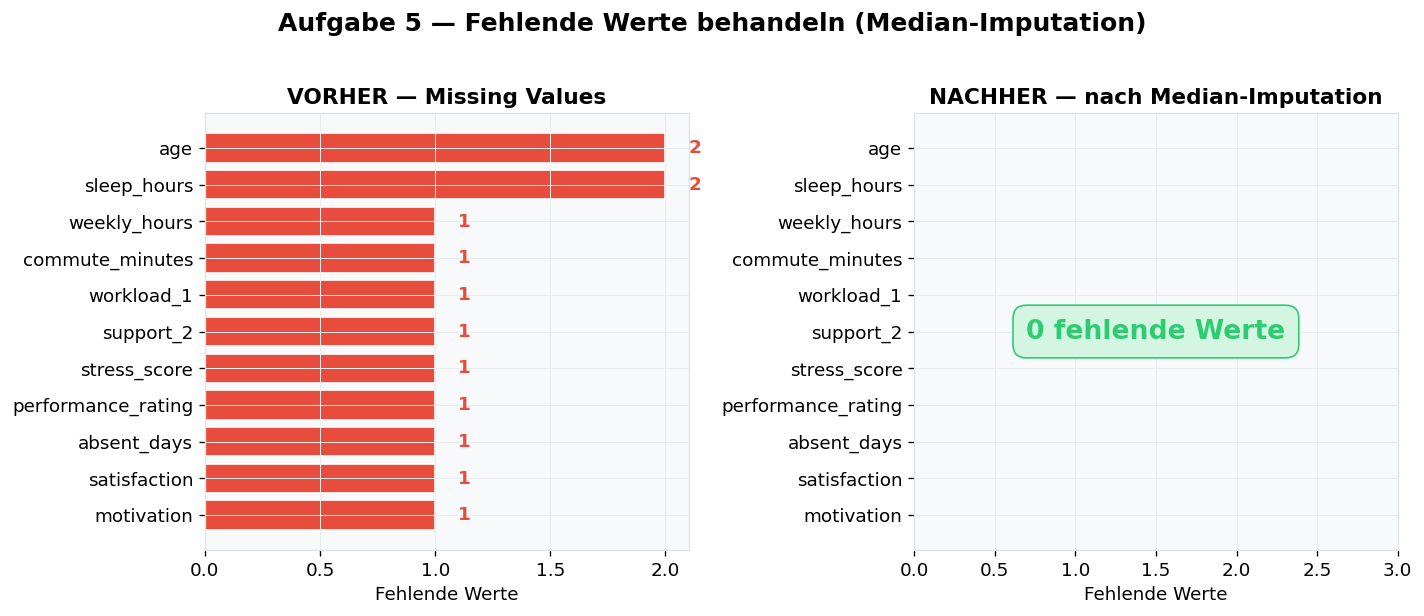

Imputierte Spalten:
                    fehlend  Median
age                     2.0   33.00
weekly_hours            1.0   40.30
sleep_hours             2.0    7.05
commute_minutes         1.0   22.00
workload_1              1.0    3.00
support_2               1.0    4.00
stress_score            1.0   42.00
motivation              1.0    3.80
satisfaction            1.0    3.60
performance_rating      1.0    3.80
absent_days             1.0    2.00


In [9]:
# --- Fehlende Werte: Vorher-Snapshot ----------------------------------------
missing_before = clean[numeric_cols].isna().sum().sort_values(ascending=False)
missing_before_nonzero = missing_before[missing_before > 0]

# --- Imputation -------------------------------------------------------------
imputed_info = {}
for col in numeric_cols:
    n_miss = clean[col].isna().sum()
    if n_miss > 0:
        median_val = clean[col].median()
        imputed_info[col] = {"fehlend": n_miss, "Median": round(median_val, 2)}
        clean[col] = clean[col].fillna(median_val)

missing_after = clean[numeric_cols].isna().sum().sum()

# --- Vorher/Nachher-Plot ----------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Links: Missing VORHER
ax = axes[0]
if len(missing_before_nonzero) > 0:
    bars = ax.barh(missing_before_nonzero.index, missing_before_nonzero.values,
                   color=C_BEFORE, edgecolor="white")
    ax.invert_yaxis()
    ax.set_xlabel("Fehlende Werte")
    ax.set_title("VORHER — Missing Values")
    for bar, v in zip(bars, missing_before_nonzero.values):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
                str(v), va="center", fontweight="bold", color=C_BEFORE)

# Rechts: Nachher = 0
ax2 = axes[1]
all_cols_missing = pd.Series(0, index=missing_before_nonzero.index)
bars2 = ax2.barh(all_cols_missing.index, all_cols_missing.values,
                 color=C_AFTER, edgecolor="white")
ax2.invert_yaxis()
ax2.set_xlabel("Fehlende Werte")
ax2.set_title("NACHHER — nach Median-Imputation")
ax2.set_xlim(0, missing_before_nonzero.max() + 1 if len(missing_before_nonzero) > 0 else 1)
ax2.text(0.5, 0.5, "0 fehlende Werte", ha="center", va="center",
         transform=ax2.transAxes, fontsize=16, fontweight="bold", color=C_AFTER,
         bbox=dict(boxstyle="round,pad=0.5", facecolor="#d5f5e3", edgecolor=C_AFTER))

fig.suptitle("Aufgabe 5 — Fehlende Werte behandeln (Median-Imputation)", y=1.02)
plt.tight_layout()
plt.show()

# Imputation-Details
if imputed_info:
    imp_df = pd.DataFrame(imputed_info).T
    print("Imputierte Spalten:")
    print(imp_df.to_string())

---
## Aufgabe 6 — Feature Engineering

Neue Variablen aus bestehenden Spalten: Skalenmittelwerte und ein zusammengesetzter Belastungsindex.

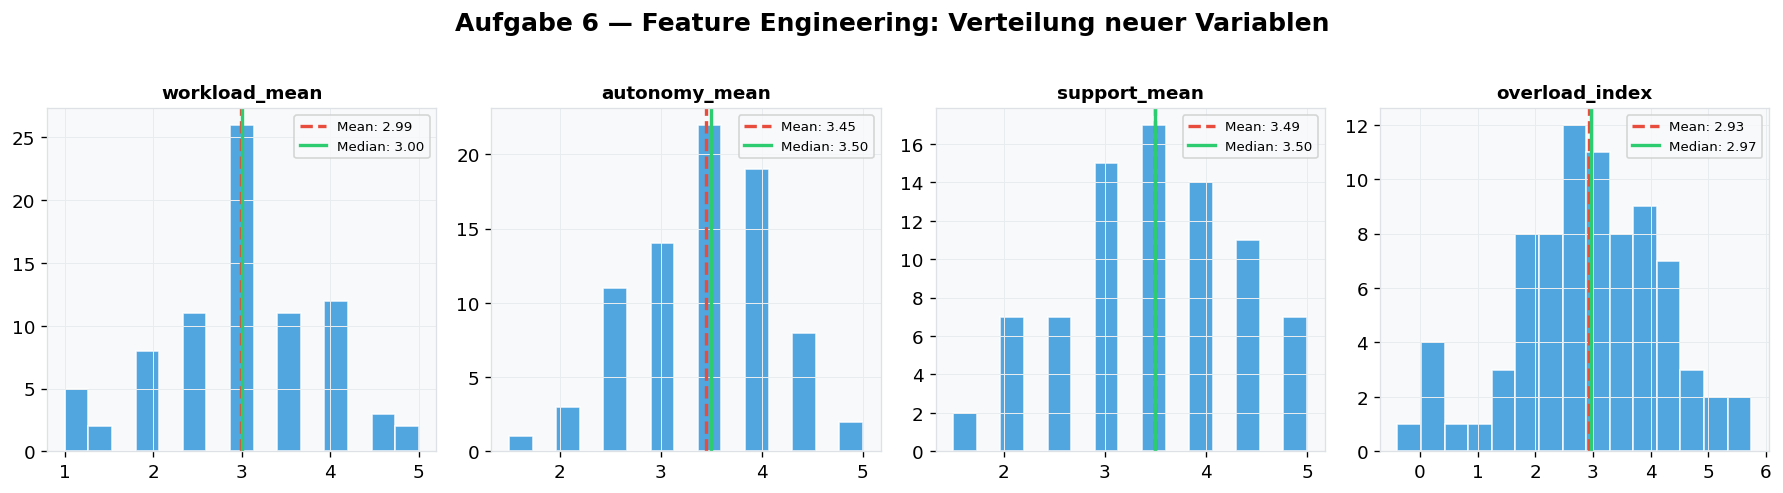

Spalten vorher (Rohdaten):    18
Spalten nachher (bereinigt):  22
Neue Features:                +4 (workload_mean, autonomy_mean, support_mean, overload_index)


In [10]:
# --- Neue Features ----------------------------------------------------------
clean["workload_mean"] = clean[["workload_1", "workload_2"]].mean(axis=1)
clean["autonomy_mean"] = clean[["autonomy_1", "autonomy_2"]].mean(axis=1)
clean["support_mean"]  = clean[["support_1", "support_2"]].mean(axis=1)
clean["overload_index"] = (
    clean["workload_mean"]
    + clean["stress_score"] / 25
    - clean["sleep_hours"] / 4
)

new_features = ["workload_mean", "autonomy_mean", "support_mean", "overload_index"]

# --- Verteilungsplots der neuen Features ------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for ax, feat in zip(axes, new_features):
    vals = clean[feat].dropna()
    ax.hist(vals, bins=15, color=C_ACCENT, edgecolor="white", alpha=0.85)
    ax.axvline(vals.mean(), color=C_BEFORE, linestyle="--", linewidth=2, label=f"Mean: {vals.mean():.2f}")
    ax.axvline(vals.median(), color=C_AFTER, linestyle="-", linewidth=2, label=f"Median: {vals.median():.2f}")
    ax.set_title(feat, fontsize=11)
    ax.legend(fontsize=8, loc="upper right")
    ax.set_xlabel("")

fig.suptitle("Aufgabe 6 — Feature Engineering: Verteilung neuer Variablen", y=1.02)
plt.tight_layout()
plt.show()

# --- Vorher/Nachher: Spaltenanzahl ------------------------------------------
n_cols_raw = raw.shape[1]
n_cols_clean = clean.shape[1]

print(f"Spalten vorher (Rohdaten):    {n_cols_raw}")
print(f"Spalten nachher (bereinigt):  {n_cols_clean}")
print(f"Neue Features:                +{n_cols_clean - n_cols_raw} ({', '.join(new_features)})")

---
## Aufgabe 7 — Model-ready Data

Zielvariable `Y` und Feature-Matrix `X` aufbauen. Kategoriale Variablen werden dummy-codiert. Korrelationsmatrix zeigt die Zusammenhänge.

In [11]:
# --- Y und X aufbauen -------------------------------------------------------
target = "satisfaction"
num_predictors = [
    "age", "weekly_hours", "sleep_hours", "commute_minutes",
    "workload_mean", "autonomy_mean", "support_mean",
    "stress_score", "motivation", "overload_index",
]
cat_predictors = ["department", "gender"]

y = clean[target]
X_num = clean[num_predictors]
X_cat = pd.get_dummies(clean[cat_predictors], drop_first=True, dtype=int)
X = pd.concat([X_num, X_cat], axis=1)

print(f"Y  (Zielvariable):   {target}  — Shape: {y.shape}")
print(f"X  (Feature-Matrix): {X.shape[1]} Prädiktoren × {X.shape[0]} Fälle")
print(f"   Numerisch:        {X_num.shape[1]} Spalten")
print(f"   Dummy-codiert:    {X_cat.shape[1]} Spalten")
print(f"\nSicherheitschecks:")
print(f"   participant_id in X: {'participant_id' in X.columns}")
print(f"   {target} in X:       {target in X.columns}")

Y  (Zielvariable):   satisfaction  — Shape: (80,)
X  (Feature-Matrix): 19 Prädiktoren × 80 Fälle
   Numerisch:        10 Spalten
   Dummy-codiert:    9 Spalten

Sicherheitschecks:
   participant_id in X: False
   satisfaction in X:       False


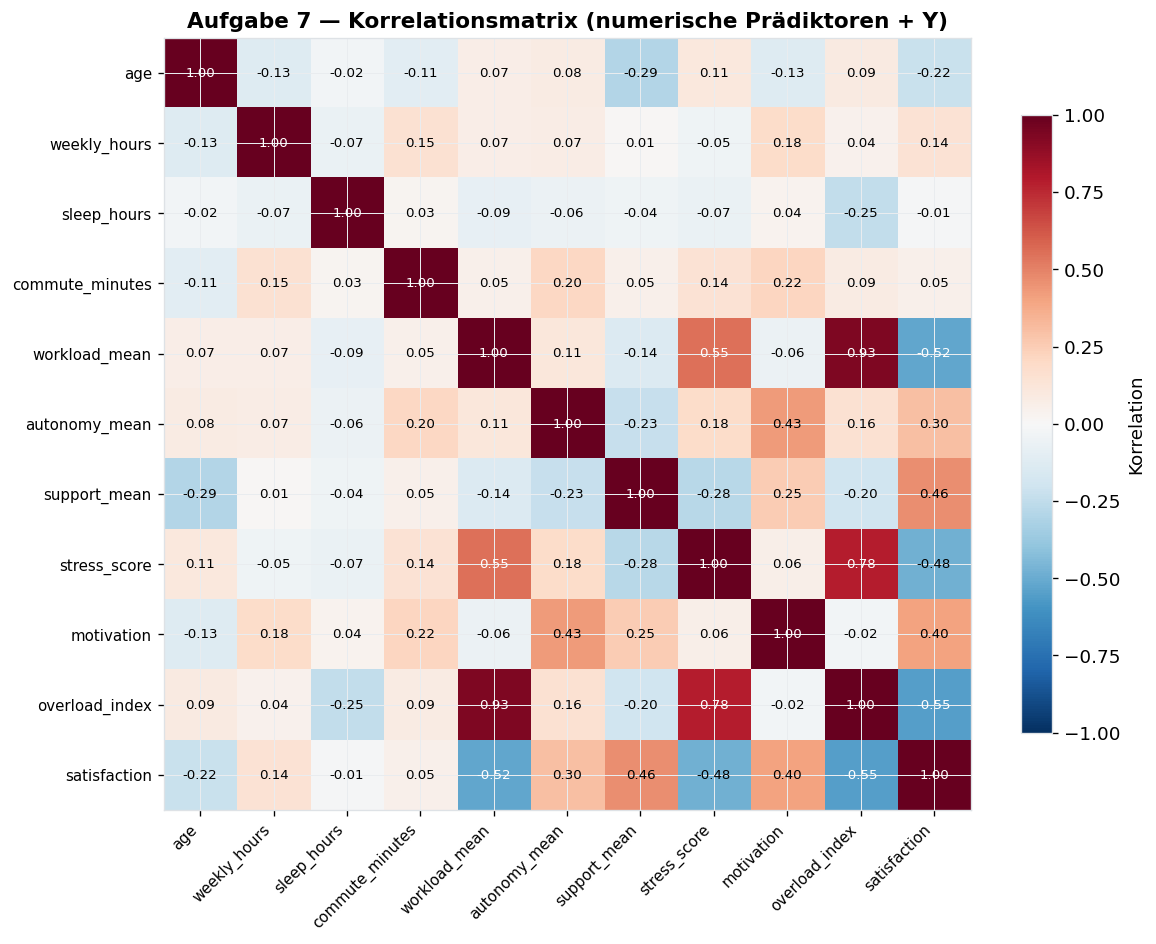


Stärkste Korrelationen mit satisfaction:
   overload_index             r = -0.552
   workload_mean              r = -0.521
   stress_score               r = -0.483
   support_mean               r = +0.462
   motivation                 r = +0.402


In [12]:
# --- Korrelationsmatrix der numerischen Prädiktoren mit Y -------------------
corr_cols = num_predictors + [target]
corr_matrix = clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(corr_cols, fontsize=9)

# Werte in Zellen
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        val = corr_matrix.values[i, j]
        color = "white" if abs(val) > 0.5 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8, color=color)

plt.colorbar(im, ax=ax, shrink=0.8, label="Korrelation")
ax.set_title("Aufgabe 7 — Korrelationsmatrix (numerische Prädiktoren + Y)")
plt.tight_layout()
plt.show()

# --- Top-Korrelationen mit Y -----------------------------------------------
corr_with_y = corr_matrix[target].drop(target).sort_values(key=abs, ascending=False)
print(f"\nStärkste Korrelationen mit {target}:")
for var, r in corr_with_y.head(5).items():
    direction = "+" if r > 0 else "-"
    print(f"   {var:25s}  r = {direction}{abs(r):.3f}")

### Scatterplots: Zusammenhänge mit der Zielvariable

Die Korrelationsmatrix zeigt Stärke und Richtung linearer Zusammenhänge als Zahl. Scatterplots machen dieselben Zusammenhänge **visuell greifbar** — inklusive Streuung, Ausreißer und möglicher Muster.

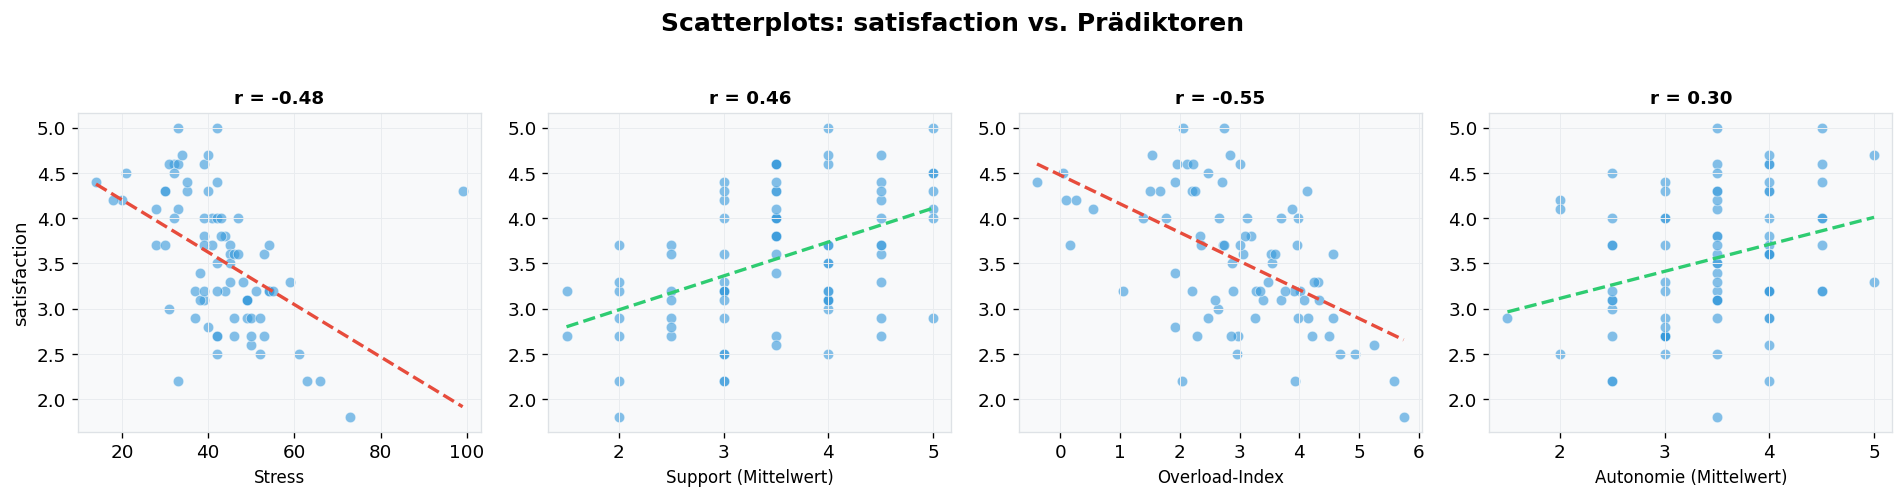

In [13]:
# --- Scatterplots: satisfaction vs. key predictors ---------------------------
scatter_pairs = [
    ("stress_score",   "Stress"),
    ("support_mean",   "Support (Mittelwert)"),
    ("overload_index", "Overload-Index"),
    ("autonomy_mean",  "Autonomie (Mittelwert)"),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (col, label) in zip(axes, scatter_pairs):
    r = clean[[col, target]].corr().iloc[0, 1]
    ax.scatter(clean[col], clean[target],
               alpha=0.6, s=40, color=C_ACCENT, edgecolor="white", linewidth=0.5)
    # Regressionsgerade
    m, b = np.polyfit(clean[col], clean[target], 1)
    x_line = np.linspace(clean[col].min(), clean[col].max(), 100)
    color_line = C_BEFORE if r < 0 else C_AFTER
    ax.plot(x_line, m * x_line + b, color=color_line, linewidth=2, linestyle="--")
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel("satisfaction" if ax == axes[0] else "")
    ax.set_title(f"r = {r:.2f}", fontsize=11)

fig.suptitle("Scatterplots: satisfaction vs. Prädiktoren", y=1.03)
plt.tight_layout()
plt.show()

---
## Aufgabe 8 — Speichern & Gesamtvergleich

Abschließender Vorher/Nachher-Überblick über den gesamten Data-Handling-Workflow.

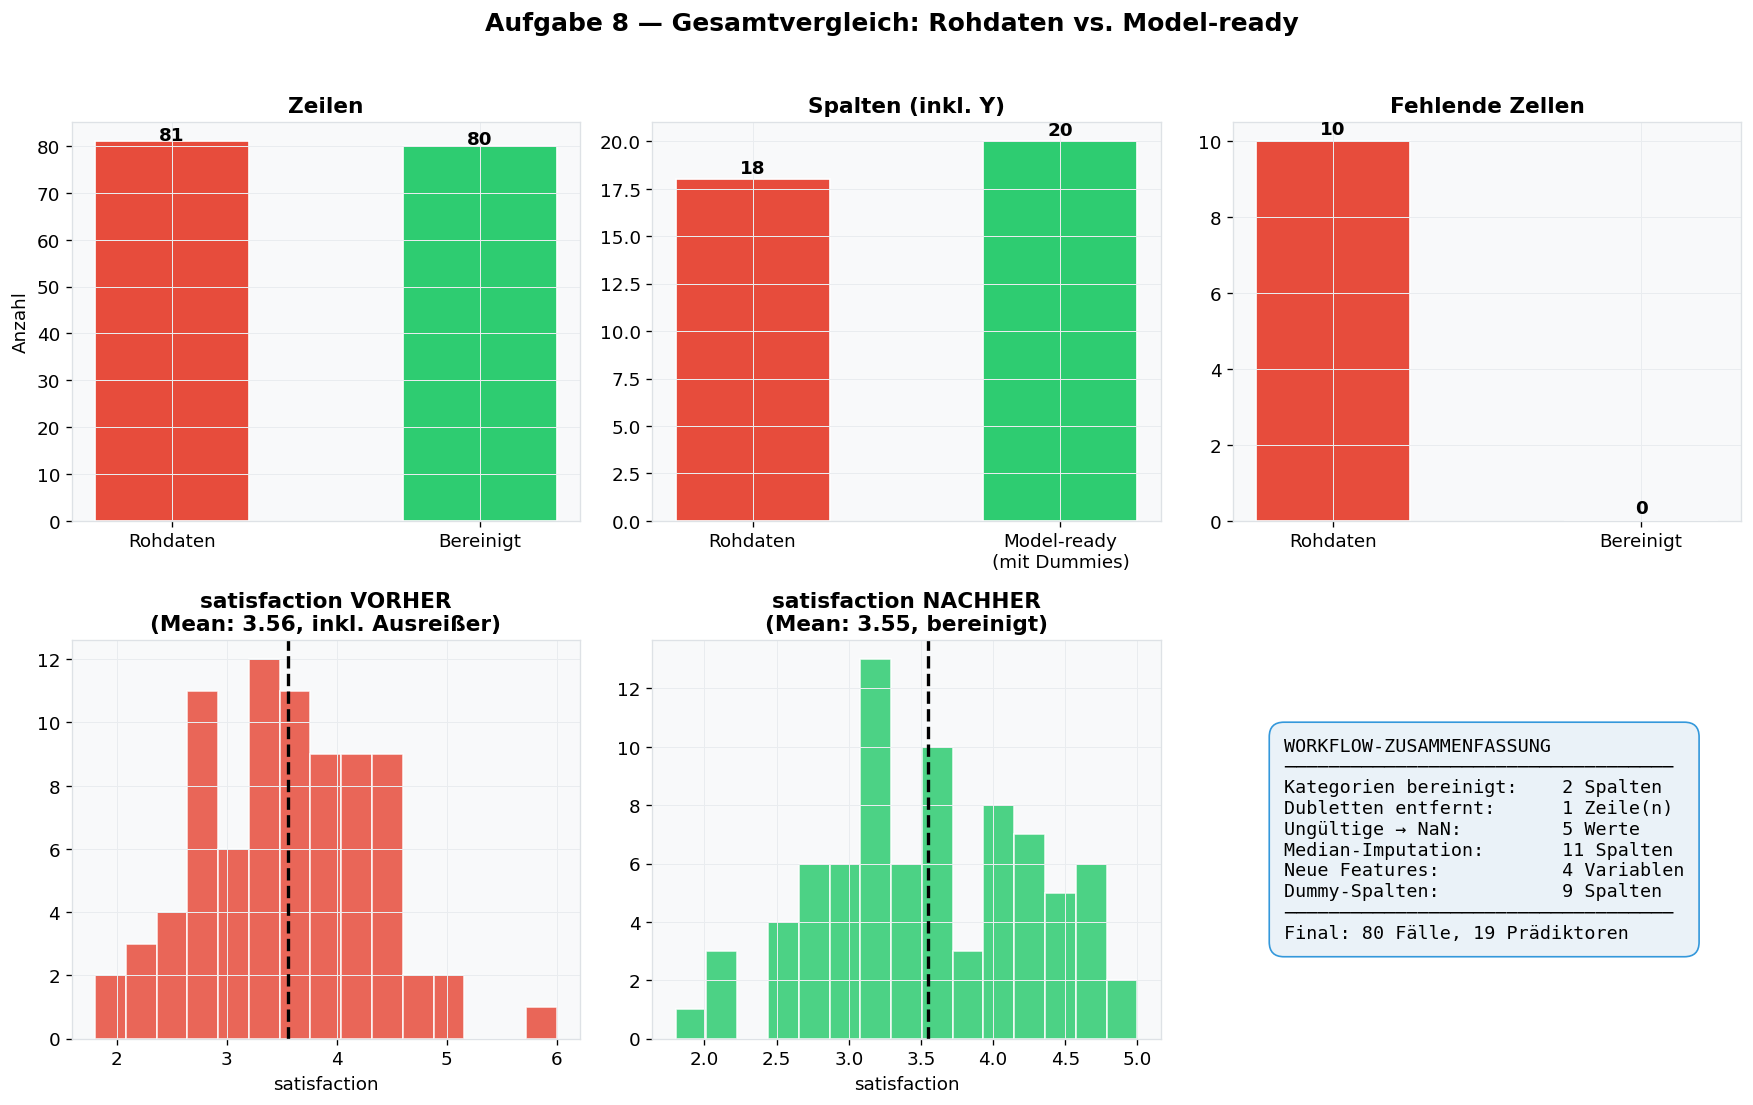

In [14]:
# --- Gesamtvergleich: Rohdaten vs. Model-ready --------------------------------
raw_nums = pd.to_numeric(raw["satisfaction"], errors="coerce")
clean_nums = clean["satisfaction"]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# (0,0) Zeilen
ax = axes[0, 0]
bars = ax.bar(["Rohdaten", "Bereinigt"], [raw.shape[0], clean.shape[0]],
              color=[C_BEFORE, C_AFTER], edgecolor="white", width=0.5)
ax.set_title("Zeilen")
ax.set_ylabel("Anzahl")
for bar, v in zip(bars, [raw.shape[0], clean.shape[0]]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            str(v), ha="center", fontweight="bold")

# (0,1) Spalten
ax = axes[0, 1]
bars = ax.bar(["Rohdaten", "Model-ready\n(mit Dummies)"],
              [raw.shape[1], X.shape[1] + 1],
              color=[C_BEFORE, C_AFTER], edgecolor="white", width=0.5)
ax.set_title("Spalten (inkl. Y)")
for bar, v in zip(bars, [raw.shape[1], X.shape[1] + 1]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            str(v), ha="center", fontweight="bold")

# (0,2) Missing Values
ax = axes[0, 2]
raw_missing = raw.isna().sum().sum()
clean_missing = clean.isna().sum().sum()
bars = ax.bar(["Rohdaten", "Bereinigt"],
              [raw_missing, clean_missing],
              color=[C_BEFORE, C_AFTER], edgecolor="white", width=0.5)
ax.set_title("Fehlende Zellen")
for bar, v in zip(bars, [raw_missing, clean_missing]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            str(v), ha="center", fontweight="bold")

# (1,0) Satisfaction Vorher
ax = axes[1, 0]
ax.hist(raw_nums.dropna(), bins=15, color=C_BEFORE, edgecolor="white", alpha=0.85)
ax.axvline(raw_nums.mean(), color="black", linestyle="--", linewidth=2)
ax.set_title(f"satisfaction VORHER\n(Mean: {raw_nums.mean():.2f}, inkl. Ausreißer)")
ax.set_xlabel("satisfaction")

# (1,1) Satisfaction Nachher
ax = axes[1, 1]
ax.hist(clean_nums.dropna(), bins=15, color=C_AFTER, edgecolor="white", alpha=0.85)
ax.axvline(clean_nums.mean(), color="black", linestyle="--", linewidth=2)
ax.set_title(f"satisfaction NACHHER\n(Mean: {clean_nums.mean():.2f}, bereinigt)")
ax.set_xlabel("satisfaction")

# (1,2) Workflow-Zusammenfassung
ax = axes[1, 2]
ax.axis("off")
summary_text = (
    f"WORKFLOW-ZUSAMMENFASSUNG\n"
    f"{'─' * 35}\n"
    f"Kategorien bereinigt:    2 Spalten\n"
    f"Dubletten entfernt:      {n_before - n_after} Zeile(n)\n"
    f"Ungültige → NaN:         {sum(replaced_nonzero.values())} Werte\n"
    f"Median-Imputation:       {len(imputed_info)} Spalten\n"
    f"Neue Features:           {len(new_features)} Variablen\n"
    f"Dummy-Spalten:           {X_cat.shape[1]} Spalten\n"
    f"{'─' * 35}\n"
    f"Final: {y.shape[0]} Fälle, {X.shape[1]} Prädiktoren"
)
ax.text(0.1, 0.5, summary_text, transform=ax.transAxes,
        fontsize=11, fontfamily="monospace", va="center",
        bbox=dict(boxstyle="round,pad=0.8", facecolor="#eaf2f8", edgecolor=C_ACCENT))

fig.suptitle("Aufgabe 8 — Gesamtvergleich: Rohdaten vs. Model-ready", y=1.02)
plt.tight_layout()
plt.show()

In [15]:
# --- Speichern ---------------------------------------------------------------
model_ready = pd.concat([clean[["participant_id", target]], X], axis=1)
model_ready.to_csv("model_ready_from_report.csv", index=False)

print(f"Gespeichert: model_ready_from_report.csv")
print(f"   {model_ready.shape[0]} Zeilen × {model_ready.shape[1]} Spalten")
print(f"   Spalten: {model_ready.columns.tolist()}")

Gespeichert: model_ready_from_report.csv
   80 Zeilen × 21 Spalten
   Spalten: ['participant_id', 'satisfaction', 'age', 'weekly_hours', 'sleep_hours', 'commute_minutes', 'workload_mean', 'autonomy_mean', 'support_mean', 'stress_score', 'motivation', 'overload_index', 'department_IT', 'department_Marketing', 'department_Operations', 'department_Sales', 'department_Unknown', 'gender_Male', 'gender_Nonbinary', 'gender_Prefer not to say', 'gender_Unknown']


---
## Fazit

Dieses Notebook wurde vollständig von **Claude** generiert und zeigt, wie ein KI-Assistent den Data-Handling-Workflow beschleunigt:

- **Diagnose**: Missing Values, Dubletten, ungültige Werte und Kategorie-Inkonsistenzen wurden automatisch erkannt und visuell aufbereitet.
- **Bereinigung**: Alle Schritte sind reproduzierbar dokumentiert und mit Vorher/Nachher-Plots belegt.
- **Feature Engineering**: Skalenmittelwerte und zusammengesetzte Indizes wurden erzeugt und auf Plausibilität geprüft.
- **Modellvorbereitung**: Y/X-Struktur mit Dummy-Codierung und Sicherheitschecks.

Der begleitende Report (`Data-Handling Report.md`) fasst die Ergebnisse als team-taugliches Dokument zusammen.